In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import seaborn as sns

import torch
import torch.nn as nn

import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, Predictive
from sklearn.preprocessing import StandardScaler
import itertools
from sklearn.metrics import mean_squared_error

from utils import Reservoir, DataGenerator, zoomed_plots

import warnings
warnings.filterwarnings("ignore")

/Users/giacomogasparotto/POD/Bayesian-Inference-in-High-Dimensional-Reservoir-Dynamics-for-Neural-Time-Series/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SSVS

Reservoir computing generates a high-dimensional state space containing hundreds of random features. Many of these features are irrelevant and can simply be interpreted as noise. Trying to learn all of them can severely slow down Bayesian inference algorithms like MCMC, a phenomenon related to the curse of dimensionality.

In order to try to work around this problem, we can implement the **Bayesian Stochastic Search Variable Selection (SSVS)** algorithm. The core idea is to introduce *sparsity* in the Reservoir parameter space by placing a "shrinking" prior (in our case, the **Horseshoe** prior) on the readout weights. 
This specific choice of prior actively shrinks the weights of useless nodes toward zero, focusing the MCMC sampling only on the most promising areas of the parameter space. 

In order to induce sparsity, the Horseshoe prior is implemented using a Half-Cauchy distribution $\mathcal{C}^{+}$:

* **Global Shrinkage:** $\tau \sim \mathcal{C}^{+}(0, 1)$
* **Local Shrinkage:** $\lambda_i \sim \mathcal{C}^{+}(0, 1)$
* **Reservoir Weights:** $\beta_i \sim \mathcal{N}(0, \lambda_i^2 \tau^2)$
* **Observation Model:** $y \sim \mathcal{N}(X\beta + b, \sigma^2)$

<p align="center">
  <img src="ssvs_horseshoe_prior_small.png" width="600">
</p>

## MG dataset

In [16]:
class SSVS:
    def __init__(self, num_samples=300, warmup_steps=100):
        self.num_samples = num_samples
        self.warmup_steps = warmup_steps
        self.mcmc = None
        
    def _model(self, X, Y=None):
        N_features = X.shape[1]
        
        # Global shrinkage 
        tau = pyro.sample("tau", dist.HalfCauchy(1.0))
        
        # Local shrinkage
        with pyro.plate("features_plate", N_features):
            lambdas = pyro.sample("lambdas", dist.HalfCauchy(1.0))
            # Regression coefficients with SSVS prior
            beta = pyro.sample("beta", dist.Normal(0.0, lambdas * tau))
            
        bias = pyro.sample("bias", dist.Normal(0.0, 10.0))
        sigma = pyro.sample("sigma", dist.Uniform(0.0, 10.0))
        
        mu = torch.matmul(X, beta) + bias
        
        if Y is not None:
            Y = Y.squeeze(-1)
        
        with pyro.plate("data_plate", X.shape[0]):
            pyro.sample("obs", dist.Normal(mu, sigma), obs=Y)

    def fit(self, X_train, Y_train):
        pyro.clear_param_store()
        
        nuts_kernel = NUTS(self._model)
        self.mcmc = MCMC(nuts_kernel, num_samples=self.num_samples, warmup_steps=self.warmup_steps)
        
        print(f"MCMC training (Samples: {self.num_samples}, Warmup: {self.warmup_steps})...")
        self.mcmc.run(X_train, Y_train)
        
        return self

    def predict(self, X_test):
        if self.mcmc is None:
            raise ValueError("The model has not been trained. Call the fit() method first.")
            
        posterior_samples = self.mcmc.get_samples()
        predictive = Predictive(self._model, posterior_samples=posterior_samples, return_sites=("obs", "beta"))
        
        return predictive(X_test)

    def evaluate_and_plot(self, X_test, Y_test, target_name="Target"):

        if self.mcmc is None:
            raise ValueError("The model has not been trained. Call the fit() method first.")

        samples = self.predict(X_test)
        y_pred_samples = samples["obs"]
        posterior_samples = self.mcmc.get_samples()
        
        # Compute statistics
        y_pred_mean = torch.median(y_pred_samples, dim=0).values.detach().numpy()
        y_lower = torch.quantile(y_pred_samples, 0.025, dim=0).detach().numpy()
        y_upper = torch.quantile(y_pred_samples, 0.975, dim=0).detach().numpy()
        y_true = Y_test.detach().numpy()
        
        # Plot 
        plt.figure(figsize=(12, 5))
        plt.plot(y_true, label="True Value", color="black", linewidth=1.5)
        plt.plot(y_pred_mean, label="Bayesian SSVS Median Forecast", color="blue", linewidth=1.5)
        plt.fill_between(range(len(y_true)), y_lower.flatten(), y_upper.flatten(), color="tab:blue", alpha=0.3, label=r"95\% Confidence Interval")
        plt.title(f"SSVS Probabilistic Forecast - {target_name}")
        plt.xlabel("Time Steps")
        plt.ylabel("Target Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Zoomed plots
        y_mean_2d = y_pred_mean.reshape(-1, 1)
        y_true_2d = y_true.reshape(-1, 1)
        y_upper_2d = y_upper.reshape(-1, 1)
        y_lower_2d = y_lower.reshape(-1, 1)
        
        zoomed_plots(
            region_idx=0, 
            y_mean=y_mean_2d, 
            y_true=y_true_2d, 
            upper=y_upper_2d, 
            lower=y_lower_2d, 
            steps=300, 
            n_plots=4, 
            rows=2
        )
    
    def compute_metrics(self, X_test, Y_test, taus=[0.025, 0.50, 0.975]):
        if self.mcmc is None:
            raise ValueError("The model has not been trained. Call the fit() method first.")
            
        samples = self.predict(X_test)
        y_pred_samples = samples["obs"]
        y_true = Y_test.detach().numpy().flatten()
        
        # Extract quantiles
        y_preds = []
        for tau in taus:
            q_val = torch.quantile(y_pred_samples, tau, dim=0).detach().numpy().flatten()
            y_preds.append(q_val)
        y_preds = np.stack(y_preds, axis=1)
        
        # MSE
        if 0.50 in taus:
            idx_median = taus.index(0.50)
            mse = np.mean((y_true - y_preds[:, idx_median])**2)
        else:
            y_median = torch.median(y_pred_samples, dim=0).values.detach().numpy().flatten()
            mse = np.mean((y_true - y_median)**2)
            
        # Coverage and width
        if 0.025 in taus and 0.975 in taus:
            y_lower = y_preds[:, taus.index(0.025)]
            y_upper = y_preds[:, taus.index(0.975)]
        else:
            y_lower = torch.quantile(y_pred_samples, 0.025, dim=0).detach().numpy().flatten()
            y_upper = torch.quantile(y_pred_samples, 0.975, dim=0).detach().numpy().flatten()
            
        coverage = np.mean((y_true >= y_lower) & (y_true <= y_upper))
        width = np.mean(y_upper - y_lower)
        
        # Calibration Error
        cal_error = 0
        for i, tau in enumerate(taus):
            emp_tau = np.mean(y_true <= y_preds[:, i])
            cal_error += (tau - emp_tau)**2
            
        # mCRPS
        crps_sum = 0
        for i, tau in enumerate(taus):
            r = y_true - y_preds[:, i]
            check_loss = np.where(r >= 0, tau * r, (tau - 1) * r)
            crps_sum += np.mean(check_loss)
        
        mcrps = (2 * crps_sum) / len(taus) 
        
        print("FINAL METRICS:")
        print(f"MSE: {mse:.4f}")
        print(f"Coverage: {coverage * 100:.2f}%")
        print(f"Mean Width: {width:.4f}")
        print(f"Calibration Error: {cal_error:.4f}")
        print(f"mCRPS: {mcrps:.4f}")

        return mse, coverage, width, cal_error, mcrps

In [17]:
# Generate Mackey-Glass dataset
Time_steps= 14000   
tau_mg = 17
n_mg = 10
beta_mg = 0.2
gamma_mg = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau_mg, n_mg, beta_mg, gamma_mg, delta_t).generate_data()

washout = 2000
X = X[washout:][::10]
Y = Y[washout:][::10]
    
train_points = int(len(X) * 0.7)

X_train = X[:train_points, :]
Y_train = Y[:train_points, :] 
X_test = X[train_points:, :]
Y_test = Y[train_points:, :]  

# Define the reservoir for Mackey-Glass
res_mg = Reservoir(input_dim=1, reservoir_dim=500, spectral_radius=0.9, seed=42)
S_train_mg = res_mg.get_states(X_train)
S_test_mg = res_mg.get_states(X_test)

# Convert to PyTorch Tensors
Xtrain_mg_t = torch.tensor(S_train_mg, dtype=torch.float32)
Ytrain_mg_t = torch.tensor(Y_train, dtype=torch.float32)
Xtest_mg_t = torch.tensor(S_test_mg, dtype=torch.float32)
Ytest_mg_t = torch.tensor(Y_test, dtype=torch.float32)

In [18]:
# Instantiate the object
ssvs_mg_model = SSVS(num_samples=300, warmup_steps=100)

In [19]:
# Fit the model
ssvs_mg_model.fit(Xtrain_mg_t, Ytrain_mg_t)

MCMC training (Samples: 300, Warmup: 100)...


Warmup:   5%|▌         | 21/400 [00:03,  4.28it/s, step size=1.57e-04, acc. prob=0.711]

KeyboardInterrupt: 

Warmup:   6%|▌         | 22/400 [00:20,  4.28it/s, step size=2.66e-04, acc. prob=0.723]

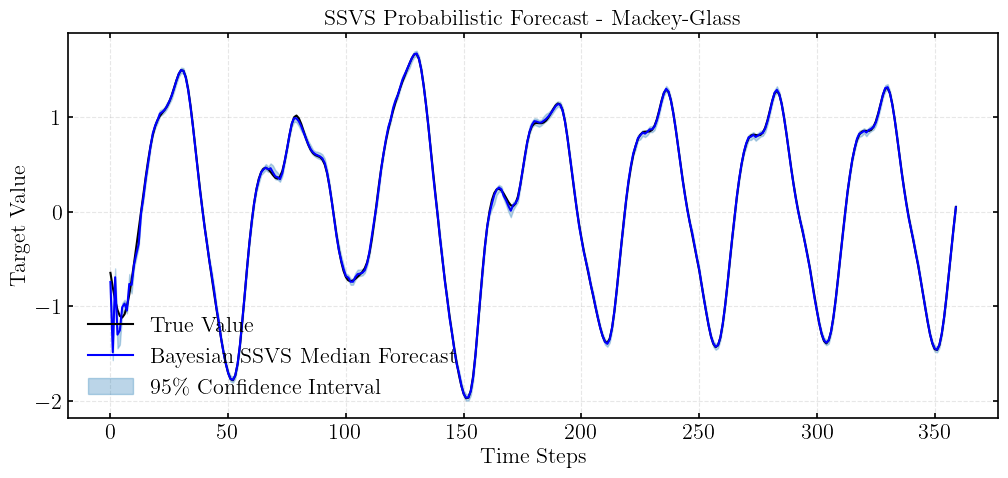

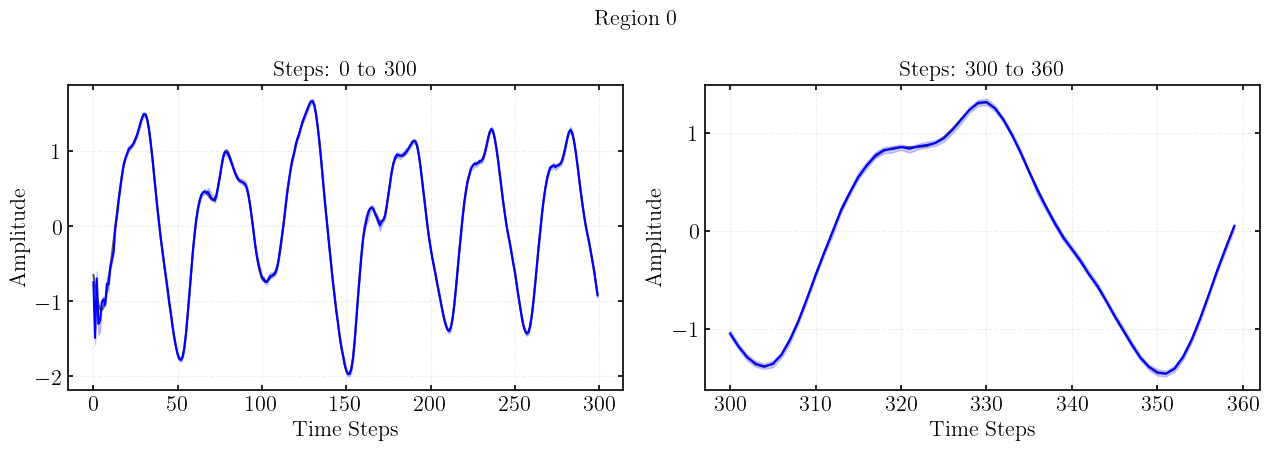

In [ ]:
# Evaluate the model
ssvs_mg_model.evaluate_and_plot(Xtest_mg_t, Ytest_mg_t, target_name="Mackey-Glass")

In [ ]:
ssvs_mg_metrics = ssvs_mg_model.compute_metrics(Xtest_mg_t, Ytest_mg_t)

# Save the metrics
ssvs_mg_mse = ssvs_mg_metrics[0]
ssvs_mg_coverage = ssvs_mg_metrics[1]
ssvs_mg_width = ssvs_mg_metrics[2]
ssvs_mg_cal_error = ssvs_mg_metrics[3]
ssvs_mg_mcrps = ssvs_mg_metrics[4]

FINAL METRICS:
MSE: 0.0021
Coverage: 93.89%
Mean Width: 0.0667
Calibration Error: 0.0015
mCRPS: 0.0086


## fMRI datset

In [ ]:
train_mat = sio.loadmat("100307.REST1.LR.SchaeferS.ptseries.mat")
test_mat = sio.loadmat("100307.REST2.LR.SchaeferS.ptseries.mat")

train_data = train_mat["tseries"].T
test_data = test_mat["tseries"].T

scaler_train = StandardScaler()
scaler_test = StandardScaler() 
train_scaled = scaler_train.fit_transform(train_data)
test_scaled = scaler_test.fit_transform(test_data)

target_reg = 0
X_tr_fmri = train_scaled[:-1, :]
Y_tr_fmri = train_scaled[1:, target_reg].reshape(-1, 1)

X_ts_fmri = test_scaled[:-1, :]
Y_ts_fmri = test_scaled[1:, target_reg].reshape(-1, 1)

X_tr_numpy = X_tr_fmri
Y_tr_numpy = Y_tr_fmri
X_ts_numpy = X_ts_fmri
Y_ts_numpy = Y_ts_fmri

In [ ]:
ssvs_fmri_model = SSVS(num_samples=300, warmup_steps=100)
ssvs_fmri_model.fit(torch.tensor(X_tr_numpy, dtype=torch.float32), torch.tensor(Y_tr_numpy, dtype=torch.float32))

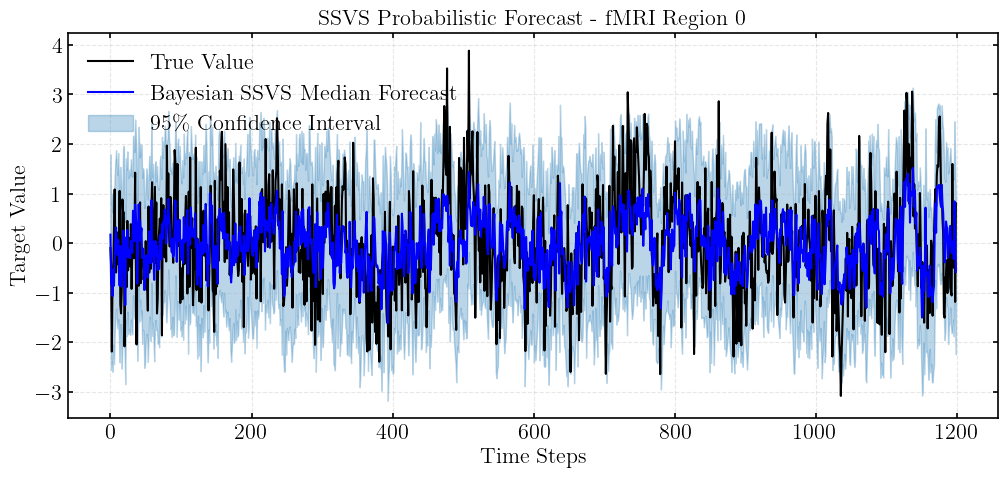

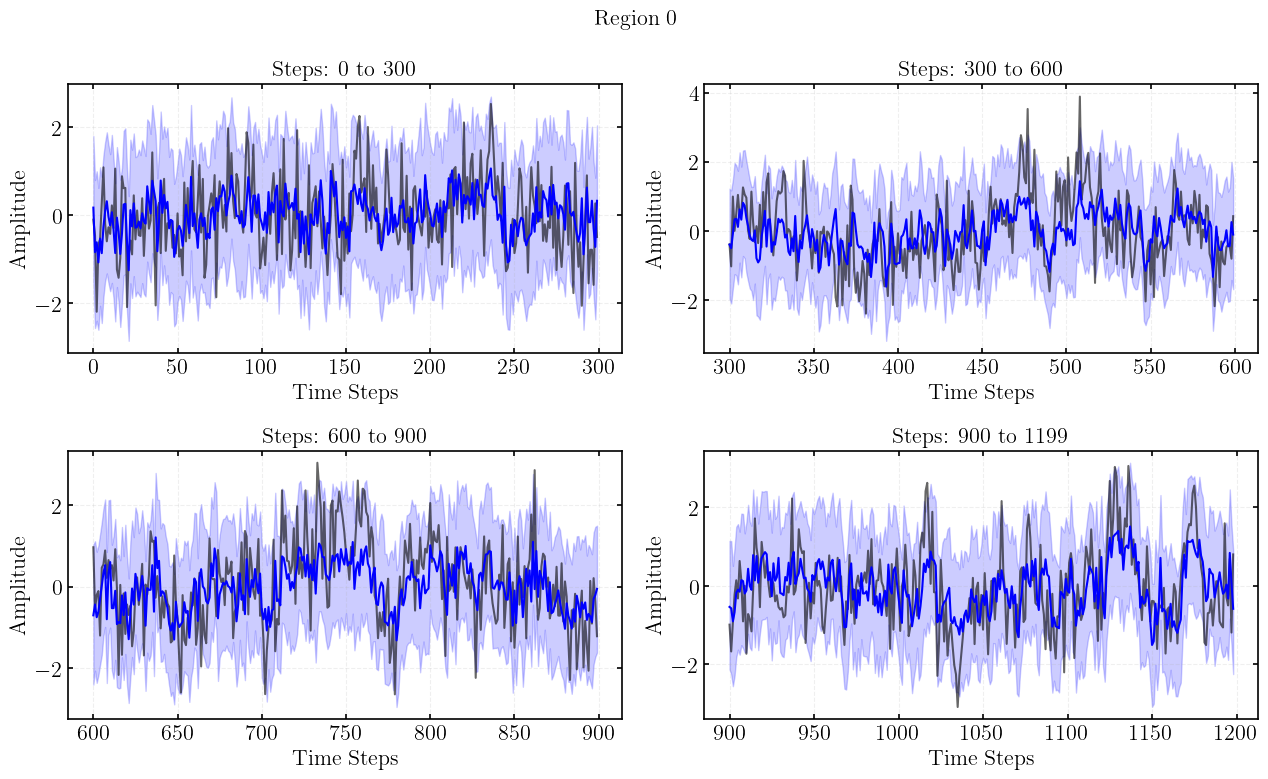

In [ ]:
# Evaluate the best model
best_res = Reservoir(input_dim=X_tr_numpy.shape[1], reservoir_dim=500, spectral_radius=best_params["spectral_radius"], seed=42)
S_test_best = best_res.get_states(X_ts_numpy)

X_test_best_t = torch.tensor(S_test_best, dtype=torch.float32)
Y_test_t = torch.tensor(Y_ts_numpy, dtype=torch.float32)

ssvs_fmri_model.evaluate_and_plot(X_test_best_t, Y_test_t, target_name=f"fMRI Region {target_reg}")

In [ ]:
ssvs_fmri_metrics = ssvs_fmri_model.compute_metrics(Xtest_mg_t, Ytest_mg_t)

# Save the metrics
ssvs_fmri_mse = ssvs_fmri_metrics[0]
ssvs_fmri_coverage = ssvs_fmri_metrics[1]
ssvs_fmri_width = ssvs_fmri_metrics[2]
ssvs_fmri_cal_error = ssvs_fmri_metrics[3]
ssvs_fmri_mcrps = ssvs_fmri_metrics[4]

FINAL METRICS:
MSE: 0.6057
Coverage: 99.72%
Mean Width: 3.2169
Calibration Error: 0.0052
mCRPS: 0.2804


 Da qua in poi è per la creazione delle heatmap, non so se qualcuno di voi abbia già scritto una funzione per crearle

In [ ]:
num_regions_to_test = train_scaled.shape[1]  

X_train = train_scaled[:-1, :]
Y_train = train_scaled[1:, :num_regions_to_test] 

X_test = test_scaled[:-1, :]
Y_test = test_scaled[1:, :num_regions_to_test]

print(f"Number of target regions for MCMC: {num_regions_to_test}")

# Initialize Reservoir
res = Reservoir(input_dim=X_train.shape[1], 
                reservoir_dim=500, 
                spectral_radius=0.5, 
                seed=42)

S_train = res.get_states(X_train)
S_test  = res.get_states(X_test)

Xtrain_tensor = torch.tensor(S_train, dtype=torch.float32)
Ytrain_tensor = torch.tensor(Y_train, dtype=torch.float32)
Xtest_tensor = torch.tensor(S_test, dtype=torch.float32)
Ytest_tensor = torch.tensor(Y_test, dtype=torch.float32)


def ssvs_model_multi(X, Y=None, num_regions=1):
    N_features = X.shape[1]
    
    # Parameters definition
    tau = pyro.sample("tau", dist.HalfCauchy(torch.ones(num_regions)))
    bias = pyro.sample("bias", dist.Normal(torch.zeros(num_regions), torch.full((num_regions,), 10.0)))
    sigma = pyro.sample("sigma", dist.Uniform(torch.zeros(num_regions), torch.full((num_regions,), 10.0)))
    
    # Sampling of Beta
    with pyro.plate("features_plate", N_features, dim=-2):
        lambdas = pyro.sample("lambdas", dist.HalfCauchy(torch.ones(num_regions)))
        beta = pyro.sample("beta", dist.Normal(torch.zeros(num_regions), lambdas * tau))
        
    mu = torch.matmul(X, beta) + bias  
    
    with pyro.plate("data_plate", X.shape[0], dim=-1):
        pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=Y)


# Training
pyro.clear_param_store()

num_samples = 200 
warmup_steps = 50

nuts_kernel = NUTS(ssvs_model_multi)
mcmc = MCMC(nuts_kernel, num_samples=num_samples, warmup_steps=warmup_steps)

print(f"\nTraining of MCMC (Samples: {num_samples}, Warmup: {warmup_steps})...")
mcmc.run(Xtrain_tensor, Ytrain_tensor, num_regions=num_regions_to_test)

# Extract results and make predictions
posterior_samples = mcmc.get_samples()
predictive = Predictive(ssvs_model_multi, posterior_samples=posterior_samples, return_sites=("obs",))

samples = predictive(Xtest_tensor, Y=None, num_regions=num_regions_to_test)
y_pred_samples = samples["obs"]

y_pred_mean = torch.median(y_pred_samples, dim=0).values.detach().numpy()
y_true = Ytest_tensor.numpy()

y_true_scaled = y_true.T
y_mean_scaled = y_pred_mean.T

Number of target regions for MCMC: 119

Training of MCMC (Samples: 200, Warmup: 50)...


Sample: 100%|██████████| 250/250 [11:05,  2.66s/it, step size=2.74e-04, acc. prob=0.336]


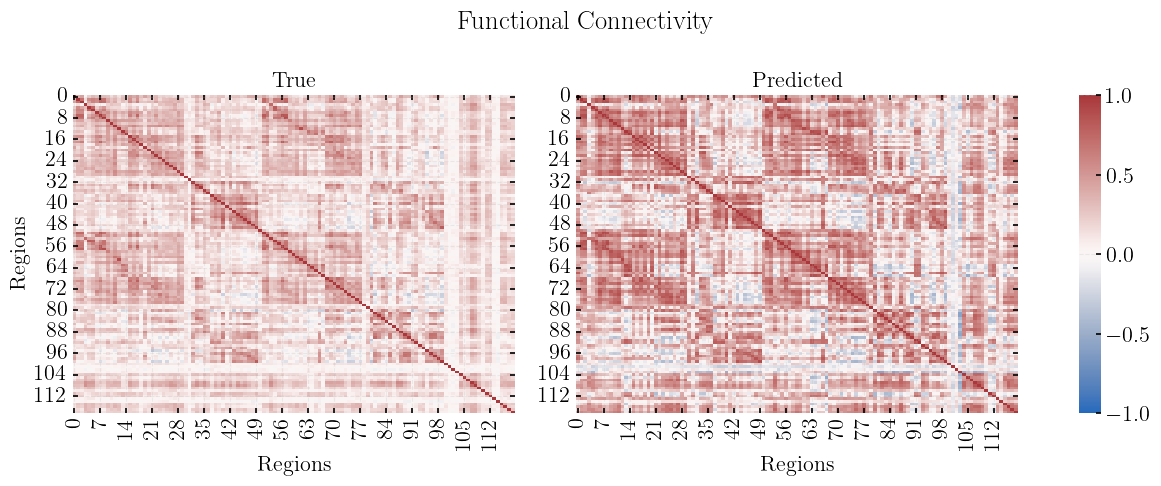

In [ ]:
import seaborn as sns
# Plot heatmaps
posterior_samples = mcmc.get_samples()
predictive = Predictive(ssvs_model_multi, posterior_samples=posterior_samples, return_sites=("obs",))

samples = predictive(Xtest_tensor, Y=None, num_regions=num_regions_to_test)
y_pred_samples = samples["obs"]

y_pred_mean = torch.median(y_pred_samples, dim=0).values.squeeze().detach().numpy()
y_true = Ytest_tensor.numpy()

y_true_scaled = y_true.T
y_mean_scaled = y_pred_mean.T


fig, ax = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle(f"Functional Connectivity")

# True
corr_true = np.corrcoef(y_true_scaled)  
sns.heatmap(corr_true, vmin=-1, vmax=1, cmap='vlag', ax=ax[0], cbar=False)
ax[0].set_title("True")
ax[0].set_xlabel("Regions")
ax[0].set_ylabel("Regions")

# Predicted
corr_pred = np.corrcoef(y_mean_scaled)  
sns.heatmap(corr_pred, vmin=-1, vmax=1, cmap='vlag', ax=ax[1], cbar=True, cbar_ax=ax[2])
ax[1].set_title("Predicted")
ax[1].set_xlabel("Regions")

plt.tight_layout()
plt.show()

# QR

Instead of relying on Bayesian inference, the authors of the paper suggested that other, more efficient methods could be implemented. One of them is a deterministic approach known as **Quantile Regression (QR)**.

We wanted to test and compare this method to see whether it could outperform the previous inference-based approaches.

Instead of predicting the expected mean by minimizing the Mean Squared Error (MSE), QR trains the readout layer to predict specific *quantiles* of the target distribution. This completely bypasses the dimensionality issues of the Reservoir and directly generates calibrated confidence intervals in a fraction of the computational time.

This model makes use of the **Pinball Loss (or Check Loss)**:

$$\rho_\tau(r) = \tau \max(r, 0) + (1-\tau)\max(-r, 0)$$

where $r = y_{true} - y_{pred}$ is the residual. By simultaneously optimizing this loss for $\tau = \{0.025, 0.50, 0.975\}$, the network learns to output the median and the bounds for the $95\%$ Confidence Interval directly.

In [ ]:
def checkloss(taus, ytrue, ypred):
    loss = 0

    # Loop over each tau
    for i, tau in enumerate(taus):
        # Compute the residuals
        r = ytrue - ypred[:, i].unsqueeze(1)
        
        # Compute the loss for a given tau
        quantile_loss = tau * torch.relu(r) + (1 - tau) * torch.relu(-r)
        loss += torch.mean(quantile_loss)
        
    return loss

## Readout layer

In [ ]:
class ReadoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation=nn.ReLU):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        # Hidden layers
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(activation())
            prev_dim = h_dim
            
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

## MG dataset

In [ ]:
# Initialize the best model
best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=best_params["hidden_dims"], output_dim=len(taus), activation=best_activation)
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"])

# Train for many epochs
epochs = 100  
train_losses = []
val_losses = []
train_mses = []
val_mses = []

print(f"Train the best model for {epochs} epochs with best params: {best_params}...")
# Training loop
for epoch in range(epochs):
    best_model.train()
    optimizer.zero_grad()
    
    # Forward and loss on training
    train_preds = best_model(Xtrain_tensor)
    loss = checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Compute metrics on Validation set
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor)
        v_loss = checkloss(taus, Ytest_tensor, val_preds)
        val_losses.append(v_loss.item())
        
        val_median = val_preds[:, 1].unsqueeze(1)
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)

print(f"Training completed! Final MSE on Validation set: {val_mses[-1]:.4f}")

In [ ]:
best_model.eval()
with torch.no_grad():
    test_predictions = best_model(Xtest_tensor)

# Extract quantiles
y_pred_025 = test_predictions[:, 0].numpy()
y_pred_50  = test_predictions[:, 1].numpy()
y_pred_975 = test_predictions[:, 2].numpy()

# Extract true values for both Train and Test
y_train_true = Ytrain_tensor.numpy()
y_test_true = Ytest_tensor.numpy()

len_train = len(y_train_true)
len_test = len(y_test_true)

# Plot results
plt.figure(figsize=(14, 5)) 

plt.plot(range(len_train), y_train_true, label="Training True Value", color="gray", alpha=0.6, linewidth=1.2)
plt.plot(range(len_train, len_train + len_test), y_test_true, label="Test True Value", color="black", linewidth=1.5)
plt.plot(range(len_train, len_train + len_test), y_pred_50, label="Median Prediction", color="blue", linestyle="--", linewidth=1.5)
plt.plot(range(len_train, len_train + len_test), y_pred_975, color="tab:blue", linestyle=":", alpha=0.7)
plt.plot(range(len_train, len_train + len_test), y_pred_025, color="tab:blue", linestyle=":", alpha=0.7)

plt.fill_between(range(len_train, len_train+len_test), y_pred_025.flatten(), y_pred_975.flatten(), 
                 color="tab:blue", alpha=0.3, label=r"95\% Confidence Interval")

plt.axvline(x=len_train, color='red', linestyle='--', alpha=0.7, label="Inference start")

plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.title(f"Probabilistic Forecasting (Best QR Model)\nParams: {best_params}")
plt.legend(loc="best", frameon=False)

plt.tight_layout()
plt.savefig("qr_mg_prediction.pdf")
plt.show()

In [ ]:
print("Final trainig on best model...")

best_activation = getattr(nn, best_params["activation"]) 

best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=best_params["hidden_dims"], output_dim=len(taus), activation=best_activation)
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"], weight_decay=1e-2)

epochs_final = 100  
val_mses = []

for epoch in range(epochs_final):
    best_model.train()
    optimizer.zero_grad()
    
    train_preds = best_model(Xtrain_tensor)
    train_preds, _ = torch.sort(train_preds, dim=1) 
    loss = checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor)
        val_preds, _ = torch.sort(val_preds, dim=1)
        val_median = val_preds[:, 1].unsqueeze(1)
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)

print(f"Training completed! Final MSE on Validation set: {val_mses[-1]:.4f}")

best_model.eval()
with torch.no_grad():
    test_predictions = best_model(Xtest_tensor)
    test_predictions, _ = torch.sort(test_predictions, dim=1)

y_pred_025 = test_predictions[:, 0].numpy()
y_pred_50  = test_predictions[:, 1].numpy()
y_pred_975 = test_predictions[:, 2].numpy()
y_true = Ytest_tensor.numpy()

Final trainig on best model...
Training completed! Final MSE on Validation set: 0.9682


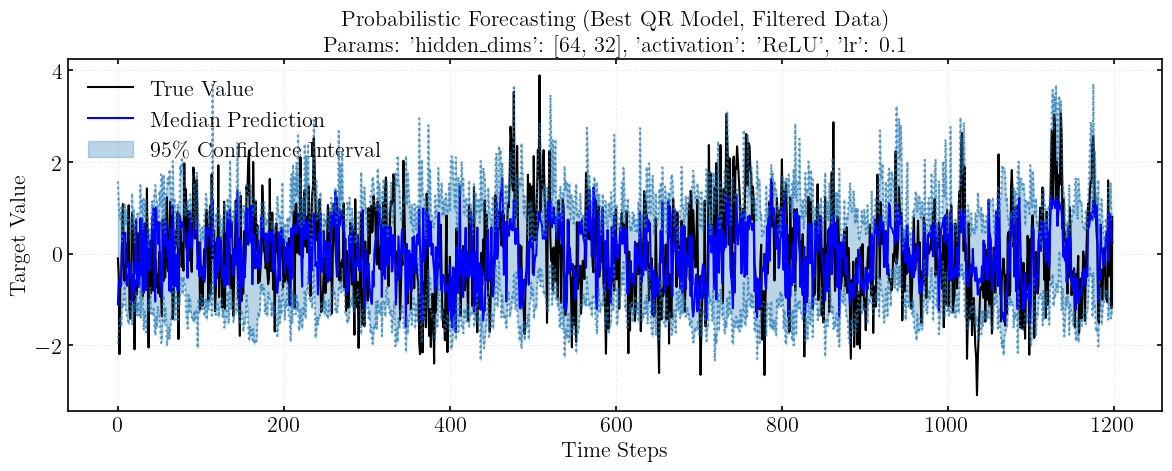

In [ ]:
# Final plot
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True Value", color="black", linewidth=1.5)
plt.plot(y_pred_50, label="Median Prediction", color="blue", linewidth=1.5)
plt.plot(y_pred_975, color="tab:blue", linestyle=":", alpha=0.7)
plt.plot(y_pred_025, color="tab:blue", linestyle=":", alpha=0.7)
plt.fill_between(range(y_true.shape[0]), y_pred_025.flatten(), y_pred_975.flatten(), color="tab:blue", alpha=0.3, label=r"95\% Confidence Interval")

plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.title(f"Probabilistic Forecasting (Best QR Model, Filtered Data)\nParams: {best_params}")
plt.legend(loc="best", frameon=False)
plt.tight_layout()
plt.savefig("qr_fmri_prediction.pdf")
plt.show()

Stessa cosa di prima sulla functional connectivity

In [ ]:
# Consider all regions
X_train_all = train_scaled[:-1, :]
Y_train_all = train_scaled[1:, :]

X_test_all = test_scaled[:-1, :]
Y_test_all = test_scaled[1:, :]

num_regions = Y_train_all.shape[1]
print(f"Number of regions: {num_regions}")
print(f"Shape X_train: {X_train_all.shape}, Shape Y_train: {Y_train_all.shape}")
print(f"Shape X_test:  {X_test_all.shape}, Shape Y_test:  {Y_test_all.shape}")

S_train_all = res.get_states(X_train_all)
S_test_all = res.get_states(X_test_all)

Xtrain_tensor = torch.from_numpy(S_train_all).float()
Ytrain_tensor = torch.from_numpy(Y_train_all).float()
Xtest_tensor = torch.from_numpy(S_test_all).float()
Ytest_tensor = torch.from_numpy(Y_test_all).float()

# Checkloss multi region
def multi_checkloss(taus, y_true, y_pred):
    y_true_exp = y_true.unsqueeze(-1) 
    taus_tensor = torch.tensor(taus, device=y_pred.device).view(1, 1, -1)
    
    r = y_true_exp - y_pred
    loss = torch.max(taus_tensor * r, (taus_tensor - 1) * r)
    return loss.mean() 

# Setup some parameters
taus = [0.025, 0.50, 0.975] 
epochs_final = 100
lr = 0.005

out_dim_total = num_regions * len(taus)

best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=[], output_dim=out_dim_total, activation=nn.Identity)
optimizer = torch.optim.Adam(best_model.parameters(), lr=lr, weight_decay=1e-2)

train_losses = []
val_mses = []

print(f"\nTraining (Output dim: {out_dim_total}) for {epochs_final} epochs...")
for epoch in range(epochs_final):
    best_model.train()
    optimizer.zero_grad()
    
    train_preds = best_model(Xtrain_tensor).view(-1, num_regions, len(taus))
    
    train_preds, _ = torch.sort(train_preds, dim=2) 
    
    loss = multi_checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Compute validation
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor).view(-1, num_regions, len(taus))
        val_preds, _ = torch.sort(val_preds, dim=2)
        val_median = val_preds[:, :, 1] 
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)
        
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, train Loss: {loss.item():.4f}, mse: {v_mse:.4f}")

print(f"Training completed! Final mse: {val_mses[-1]:.4f}")

with torch.no_grad():
    test_predictions = best_model(Xtest_tensor).view(-1, num_regions, len(taus))
    test_predictions, _ = torch.sort(test_predictions, dim=2)

# Extract the medians for all regions
y_pred_50_all = test_predictions[:, :, 1].numpy()  
y_true_all = Ytest_tensor.numpy()                 

y_true_scaled = y_true_all.T
y_mean_scaled = y_pred_50_all.T

Number of regions: 119
Shape X_train: (1199, 119), Shape Y_train: (1199, 119)
Shape X_test:  (1199, 119), Shape Y_test:  (1199, 119)

Training (Output dim: 357) for 100 epochs...
Epoch 0, train Loss: 0.3099, mse: 0.8997
Epoch 10, train Loss: 0.1759, mse: 0.7578
Epoch 20, train Loss: 0.1706, mse: 0.7507
Epoch 30, train Loss: 0.1736, mse: 0.7498
Epoch 40, train Loss: 0.1734, mse: 0.7476
Epoch 50, train Loss: 0.1720, mse: 0.7455
Epoch 60, train Loss: 0.1719, mse: 0.7453
Epoch 70, train Loss: 0.1721, mse: 0.7455
Epoch 80, train Loss: 0.1719, mse: 0.7450
Epoch 90, train Loss: 0.1719, mse: 0.7453
Training completed! Final mse: 0.7454


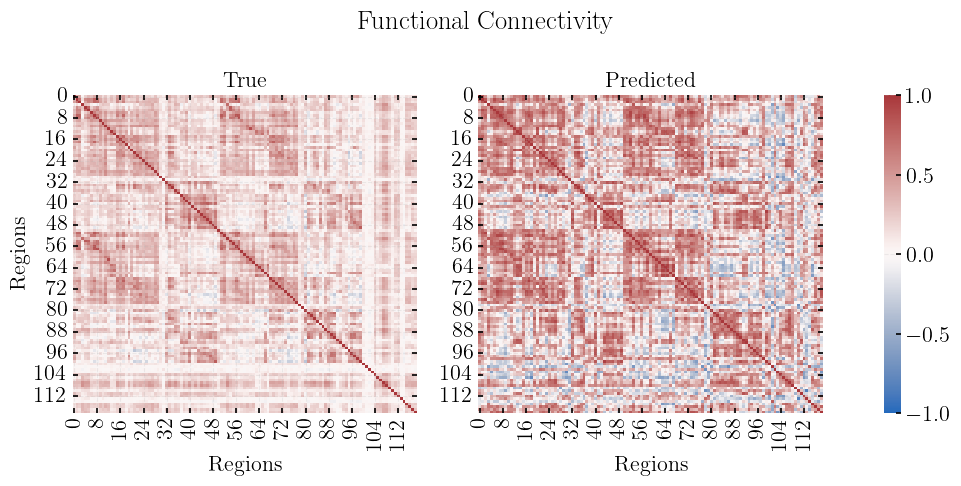

In [ ]:
# Plot the functional connectivity heatmaps
fig, ax = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle("Functional Connectivity")

# True
corr_true = np.corrcoef(y_true_scaled) 
sns.heatmap(corr_true, vmin=-1, vmax=1, cmap='vlag', ax=ax[0], cbar=False)
ax[0].set_title("True")
ax[0].set_xlabel("Regions")
ax[0].set_ylabel("Regions")

# Predicted
corr_pred = np.corrcoef(y_mean_scaled)
sns.heatmap(corr_pred, vmin=-1, vmax=1, cmap='vlag', ax=ax[1], cbar=True, cbar_ax=ax[2])
ax[1].set_title("Predicted")
ax[1].set_xlabel("Regions")

plt.tight_layout()
plt.savefig("qr_fmri_functional_connectivity.pdf")
plt.show()

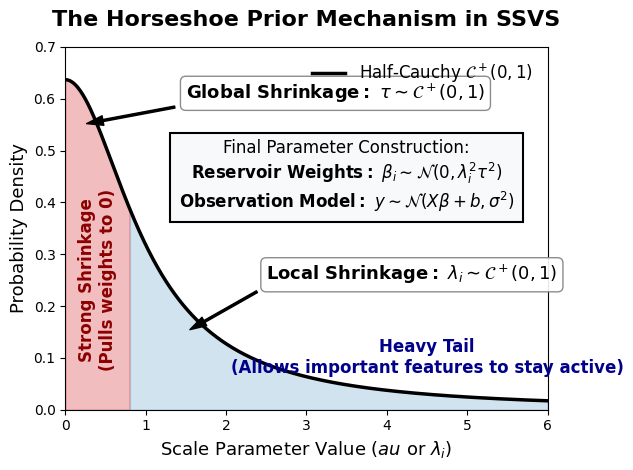

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import halfcauchy

# Generiamo i dati per la distribuzione Half-Cauchy
x = np.linspace(0, 6, 1000)
# Usiamo scala=1 come nel tuo modello (HalfCauchy(1.0))
y = halfcauchy.pdf(x, loc=0, scale=1)

# Setup della figura
fig, ax = plt.subplots(figsize=(10, 6))

# Plot della curva di densità
ax.plot(x, y, color='black', lw=2.5, label=r'Half-Cauchy $\mathcal{C}^+(0, 1)$')

# 1. Evidenziamo il picco allo zero (Shrinkage fortissimo)
ax.fill_between(x[x <= 0.8], y[x <= 0.8], color='tab:red', alpha=0.3)
ax.text(0.4, 0.25, 'Strong Shrinkage\n(Pulls weights to 0)', 
        ha='center', va='center', color='darkred', fontsize=12, fontweight='bold', rotation=90)

# 2. Evidenziamo la "Heavy Tail" (Pesi che sopravvivono)
ax.fill_between(x[x > 0.8], y[x > 0.8], color='tab:blue', alpha=0.2)
ax.text(4.5, 0.1, 'Heavy Tail\n(Allows important features to stay active)', 
        ha='center', va='center', color='darkblue', fontsize=12, fontweight='bold')

# --- AGGIUNTA DELLE FORMULE SUL GRAFICO ---

# Annotazione per tau (Global Shrinkage)
ax.annotate(r'$\mathbf{Global\ Shrinkage:}\ \tau \sim \mathcal{C}^+(0, 1)$', 
            xy=(0.2, 0.55), xytext=(1.5, 0.6),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
            fontsize=13, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

# Annotazione per lambda (Local Shrinkage)
ax.annotate(r'$\mathbf{Local\ Shrinkage:}\ \lambda_i \sim \mathcal{C}^+(0, 1)$', 
            xy=(1.5, 0.15), xytext=(2.5, 0.25),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
            fontsize=13, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

# Box riassuntivo con le equazioni di combinazione
eq_text = (
    "Final Parameter Construction:\n"
    r"$\mathbf{Reservoir\ Weights:}\ \beta_i \sim \mathcal{N}(0, \lambda_i^2 \tau^2)$" + "\n"
    r"$\mathbf{Observation\ Model:}\ y \sim \mathcal{N}(X\beta + b, \sigma^2)$"
)

bbox_props = dict(boxstyle="square,pad=0.5", fc="#f8f9fa", ec="black", lw=1.5)
ax.text(3.5, 0.45, eq_text, ha='center', va='center', bbox=bbox_props, fontsize=12)

# Formattazione estetica del grafico
ax.set_title('The Horseshoe Prior Mechanism in SSVS', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Scale Parameter Value ($\tau$ or $\lambda_i$)', fontsize=13)
ax.set_ylabel('Probability Density', fontsize=13)
ax.set_xlim(0, 6)
ax.set_ylim(0, 0.7)
#ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig("ssvs_horseshoe_prior.png")
plt.show()

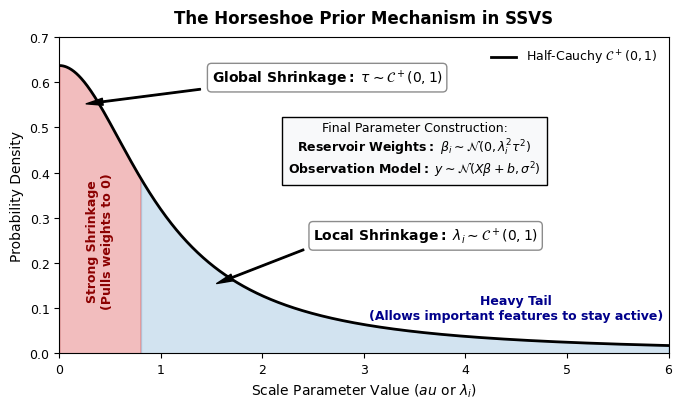

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import halfcauchy

# Generiamo i dati per la distribuzione Half-Cauchy
x = np.linspace(0, 6, 1000)
# Usiamo scala=1 come nel tuo modello (HalfCauchy(1.0))
y = halfcauchy.pdf(x, loc=0, scale=1)

# Setup della figura RIDIMENSIONATA proporzionalmente
fig, ax = plt.subplots(figsize=(7, 4.2))

# Plot della curva di densità
ax.plot(x, y, color='black', lw=2.0, label=r'Half-Cauchy $\mathcal{C}^+(0, 1)$')

# 1. Evidenziamo il picco allo zero (Shrinkage fortissimo)
ax.fill_between(x[x <= 0.8], y[x <= 0.8], color='tab:red', alpha=0.3)
ax.text(0.4, 0.25, 'Strong Shrinkage\n(Pulls weights to 0)', 
        ha='center', va='center', color='darkred', fontsize=9, fontweight='bold', rotation=90)

# 2. Evidenziamo la "Heavy Tail" (Pesi che sopravvivono)
ax.fill_between(x[x > 0.8], y[x > 0.8], color='tab:blue', alpha=0.2)
ax.text(4.5, 0.1, 'Heavy Tail\n(Allows important features to stay active)', 
        ha='center', va='center', color='darkblue', fontsize=9, fontweight='bold')

# --- AGGIUNTA DELLE FORMULE SUL GRAFICO ---

# Annotazione per tau (Global Shrinkage)
ax.annotate(r'$\mathbf{Global\ Shrinkage:}\ \tau \sim \mathcal{C}^+(0, 1)$', 
            xy=(0.2, 0.55), xytext=(1.5, 0.6),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.0, headwidth=5),
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

# Annotazione per lambda (Local Shrinkage)
ax.annotate(r'$\mathbf{Local\ Shrinkage:}\ \lambda_i \sim \mathcal{C}^+(0, 1)$', 
            xy=(1.5, 0.15), xytext=(2.5, 0.25),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.0, headwidth=5),
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

# Box riassuntivo con le equazioni di combinazione
eq_text = (
    "Final Parameter Construction:\n"
    r"$\mathbf{Reservoir\ Weights:}\ \beta_i \sim \mathcal{N}(0, \lambda_i^2 \tau^2)$" + "\n"
    r"$\mathbf{Observation\ Model:}\ y \sim \mathcal{N}(X\beta + b, \sigma^2)$"
)

bbox_props = dict(boxstyle="square,pad=0.5", fc="#f8f9fa", ec="black", lw=1.0)
ax.text(3.5, 0.45, eq_text, ha='center', va='center', bbox=bbox_props, fontsize=9)

# Formattazione estetica del grafico
ax.set_title('The Horseshoe Prior Mechanism in SSVS', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Scale Parameter Value ($\tau$ or $\lambda_i$)', fontsize=10)
ax.set_ylabel('Probability Density', fontsize=10)
ax.set_xlim(0, 6)
ax.set_ylim(0, 0.7)
ax.tick_params(axis='both', which='major', labelsize=9)
ax.legend(loc='upper right', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("ssvs_horseshoe_prior_small.png", dpi=300) # Salvato in alta qualità nonostante le dimensioni
plt.show()